In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf

# Load the Pascal VOC 2007 dataset (only using the 'train' split for simplicity)
ds_train = tfds.load('voc/2007', split='train', shuffle_files=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2007/incomplete.2XQF1C_4.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2007/incomplete.2XQF1C_4.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2007/4.0.0. Subsequent calls will reuse this data.


In [ ]:
NUM_CLASSES = 20  # Pascal VOC has 20 object classes

def preprocess(example):
    # Resize image to a fixed size (e.g., 224 x 224)
    image = tf.image.resize(example['image'], (224, 224))
    image = tf.cast(image, tf.float32) / 255.0

    # For demonstration, select the first object
    bbox = example['objects']['bbox'][0]     # shape: (4,)
    label = example['objects']['label'][0]     # label as an integer

    # Convert the label to one-hot encoding
    label = tf.one_hot(label, depth=NUM_CLASSES)

    return image, {'bbox': bbox, 'class': label}

# Apply preprocessing and prepare batches
ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.batch(8).prefetch(tf.data.AUTOTUNE)


In [ ]:
from tensorflow.keras import layers, models, optimizers

def create_simple_object_detection_model(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Simple Convolutional Backbone
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)

    # Bounding Box Regression Head
    bbox_output = layers.Dense(4, activation='linear', name='bbox')(x)

    # Classification Head
    class_output = layers.Dense(num_classes, activation='softmax', name='class')(x)

    model = models.Model(inputs=inputs, outputs=[bbox_output, class_output])
    return model

# Create and compile the model
model = create_simple_object_detection_model()
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss={'bbox': 'mse', 'class': 'categorical_crossentropy'},
              metrics={'bbox': 'mae', 'class': 'accuracy'})

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 16)   │            448 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 16)   │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 32)   │          4,640 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 56, 56, 32)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 56, 56, 64)     │         18,496 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 28, 28, 64)     │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 50176)          │              0 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bbox (Dense)              │ (None, 4)              │        200,708 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ class (Dense)             │ (None, 20)             │      1,003,540 │ flatten[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,227,832 (4.68 MB)

 Trainable params: 1,227,832 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model on the preprocessed VOC data
model.fit(ds_train, epochs=10)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - bbox_loss: 0.1341 - bbox_mae: 0.2670 - class_accuracy: 0.1652 - class_loss: 2.8299 - loss: 2.9639
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - bbox_loss: 0.0604 - bbox_mae: 0.1949 - class_accuracy: 0.2859 - class_loss: 2.3434 - loss: 2.4038
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - bbox_loss: 0.1482 - bbox_mae: 0.2860 - class_accuracy: 0.5568 - class_loss: 1.4802 - loss: 1.6284
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - bbox_loss: 0.2990 - bbox_mae: 0.3797 - class_accuracy: 0.8164 - class_loss: 0.7758 - loss: 1.0748
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - bbox_loss: 0.2698 - bbox_mae: 0.3621 - class_accuracy: 0.9247 - class_loss: 0.4553 - loss: 0.7251
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - bbox_loss: 0.1730 - bbox_mae: 0.3070 - class_accuracy: 0.9665 - class_loss: 0.2288 - loss: 0.4019
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - bbox_loss: 0.2220 - bbox_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [ 49,  42,  32],
        [ 49,  44,  33],
        [ 46,  42,  32]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [ 56,  49,  39],
        [ 56,  46,  34],
        [ 55,  46,  33]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [ 58,  59,  53],
        ...,
        [ 55,  48,  38],
        [ 54,  47,  33],
        [ 51,  46,  31]],

       ...,

       [[101,  42,   3],
        [ 99,  41,   2],
        [ 97,  43,   0],
        ...,
        [140, 140, 140],
        [122, 124, 123],
        [121, 123, 122]],

       [[ 98,  39,   0],
        [102,  45,   2],
        [102,  45,   0],
        ...,
        [132, 132, 132],
        [121, 123, 122],
        [136, 136, 136]],

       [[100,  41,   0],
        [100,  41,   0],
        [109,  52,   4],
        ...,
        [126, 126, 128],
        [143, 144, 143],
        [132, 132, 131]]], dtype=uint8)
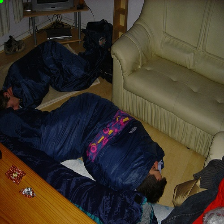

In [ ]:
import cv2
import numpy as np

# Get one batch of images from the training set (for demonstration)
images, targets = next(iter(ds_train))
pred_bbox, pred_class = model.predict(images)

# Process the first image in the batch
test_image = images[0].numpy()
predicted_bbox = pred_bbox[0].astype(int)
predicted_label_index = np.argmax(pred_class[0])
voc_labels = {i: f"Class_{i}" for i in range(NUM_CLASSES)}  # Replace with VOC class names if desired
predicted_label = voc_labels[predicted_label_index]

# Convert image back to uint8 for visualization
test_image_vis = (test_image * 255).astype(np.uint8)

# Extract coordinates (assuming [ymin, xmin, ymax, xmax] format)
# Adjust if needed (the VOC TFDS dataset returns boxes as [ymin, xmin, ymax, xmax])
ymin, xmin, ymax, xmax = predicted_bbox
cv2.rectangle(test_image_vis, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
cv2.putText(test_image_vis, predicted_label, (xmin, ymin - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)




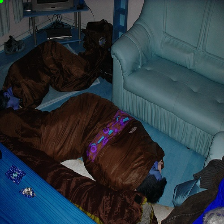

In [ ]:


import cv2
import numpy as np
from google.colab.patches import cv2_imshow #

# Display the image (if using a local environment with GUI support)
cv2_imshow(test_image_vis)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
print(pred_class[0])

[1.56444491e-06 3.08020622e-04 6.60256203e-03 6.70781941e-04
 4.15741466e-03 1.12577596e-04 3.35810916e-03 5.72070703e-02
 5.08894911e-03 8.32020305e-05 8.83546076e-04 1.02404971e-02
 1.74597371e-04 2.69172154e-03 8.88808370e-01 1.60598702e-05
 2.38665980e-05 4.15981375e-03 3.82430688e-03 1.15870507e-02]


In [ ]:
print("Predicted BBox:", predicted_bbox)


Predicted BBox: [0 0 1 1]


In [ ]:
predicted_bbox = np.clip(predicted_bbox, 0, 223)


In [ ]:
voc_labels = {i: f"Class_{i}" for i in range(NUM_CLASSES)}


In [ ]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 224, 224, 16)   │            448 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 112, 112, 16)   │              0 │ conv2d_6[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 112, 112, 32)   │          4,640 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 56, 56, 32)     │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 56, 56, 64)     │         18,496 │ max_pooling2d_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 28, 28, 64)     │              0 │ conv2d_8[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 50176)          │              0 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bbox (Dense)              │ (None, 4)              │        200,708 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ class (Dense)             │ (None, 20)             │      1,003,540 │ flatten_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,227,832 (4.68 MB)

 Trainable params: 1,227,832 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - bbox_loss: 0.2251 - bbox_mae: 0.3581 - class_accuracy: 0.1495 - class_loss: 2.9040 - loss: 3.1291
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - bbox_loss: 0.0576 - bbox_mae: 0.1945 - class_accuracy: 0.2212 - class_loss: 2.5390 - loss: 2.5967
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - bbox_loss: 0.0547 - bbox_mae: 0.1845 - class_accuracy: 0.3745 - class_loss: 2.0061 - loss: 2.0612
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - bbox_loss: 0.1490 - bbox_mae: 0.2948 - class_accuracy: 0.6466 - class_loss: 1.1943 - loss: 1.3435
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - bbox_loss: 0.2704 - bbox_mae: 0.3777 - class_accuracy: 0.8256 - class_loss: 0.7279 - loss: 0.9985
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - bbox_loss: 0.2161 - bbox_mae: 0.3332 - class_accuracy: 0.9125 - class_loss: 0.4401 - loss: 0.6562
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - bbox_loss: 0.2094 - bbox_mae: 0.3281 -

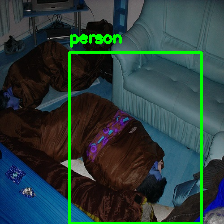

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from tensorflow.keras import layers, models, optimizers

# Define the number of classes (VOC has 20 classes)
NUM_CLASSES = 20

# Preprocessing function: resize, normalize, and extract the first object's bbox and label
def preprocess(sample):
    # Load and resize the image
    image = sample['image']
    image = tf.image.resize(image, (224, 224))  # Resize to match the model input
    image = tf.cast(image, tf.float32) / 255.0   # Normalize to [0, 1]

    # Extract the first object's bounding box and label
    # VOC objects are stored in the 'objects' dict with keys 'bbox' and 'label'
    objects = sample['objects']
    # In case an image has no objects, you might want to filter these out in a full pipeline.
    bbox = objects['bbox'][0]  # Normalized bbox: [ymin, xmin, ymax, xmax]
    label = objects['label'][0]  # Integer label

    # One-hot encode the label for the classification head
    label_onehot = tf.one_hot(label, depth=NUM_CLASSES)

    # Create a dictionary for targets matching our model outputs
    target = {'bbox': bbox, 'class': label_onehot}
    return image, target

# Load the Pascal VOC 2007 dataset ('train' split for simplicity)
ds_train = tfds.load('voc/2007', split='train', shuffle_files=True)
# Map the preprocessing function and batch the dataset
ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.batch(32).prefetch(tf.data.AUTOTUNE)

# Define a simple object detection model with a shared backbone and two heads
def create_simple_object_detection_model(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Simple Convolutional Backbone
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)

    # Bounding Box Regression Head (outputs normalized coordinates: [ymin, xmin, ymax, xmax])
    bbox_output = layers.Dense(4, activation='linear', name='bbox')(x)

    # Classification Head
    class_output = layers.Dense(num_classes, activation='softmax', name='class')(x)

    model = models.Model(inputs=inputs, outputs=[bbox_output, class_output])
    return model

# Create and compile the model
model = create_simple_object_detection_model()
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss={'bbox': 'mse', 'class': 'categorical_crossentropy'},
              metrics={'bbox': 'mae', 'class': 'accuracy'})
model.summary()

# Train the model (adjust epochs as needed)
model.fit(ds_train, epochs=10)

# Get one batch of images from the training set for demonstration
images, targets = next(iter(ds_train))
pred_bbox, pred_class = model.predict(images)

# Process the first image in the batch
test_image = images[0].numpy()  # Convert tensor to numpy array
# For visualization, convert bbox coordinates to pixel values
# Since the model outputs normalized coordinates, multiply by the image dimensions (224 in our case)
predicted_bbox = (pred_bbox[0] * 224).astype(int)
predicted_label_index = np.argmax(pred_class[0])

# Define VOC class names
voc_labels = {
    0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
    5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
    10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike',
    14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa',
    18: 'train', 19: 'tvmonitor'
}
predicted_label = voc_labels.get(predicted_label_index, "Unknown")

# Convert image back to uint8 for visualization (assuming the image was normalized)
test_image_vis = (test_image * 255).astype(np.uint8)

# Clip bounding box coordinates to ensure they lie within the image dimensions
height, width, _ = test_image_vis.shape
ymin, xmin, ymax, xmax = np.clip(predicted_bbox, 0, [height - 1, width - 1, height - 1, width - 1])

# Draw the bounding box and label on the image
cv2.rectangle(test_image_vis, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
cv2.putText(test_image_vis, predicted_label, (xmin, max(0, ymin - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display the image (using colab's cv2_imshow)
cv2_imshow(test_image_vis)
cv2.waitKey(0)
cv2.destroyAllWindows()
